In [1]:
import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt

from nbtools import auto_plot_style

In [2]:
%matplotlib inline
auto_plot_style()

In [3]:
def load_data(path):
    fieldlines = pd.read_csv(path, skiprows=8, names=['r', 'z', 'id', 'field'], sep=r'\s+')
    fieldlines['field'] = fieldlines['field']/100
    fieldlines['r'] *= 1e3 # in mm
    fieldlines['z'] *= 1e3 # in mm
    add_drift_distance(fieldlines)

    return fieldlines

def add_drift_distance(fieldlines):
    fieldlines['delta_dist'] = np.zeros(len(fieldlines))
    fieldlines['total_dist'] = np.zeros(len(fieldlines))
    for i in fieldlines.id.unique()[:]:
        sel_line = fieldlines.id == i
        data     = fieldlines[sel_line]    
        d        = np.diff(data.loc[:, ['r', 'z']].values, axis=0)
        segdists = np.sqrt((d ** 2).sum(axis=1))
        fieldlines.loc[sel_line, 'delta_dist'] = np.concatenate(([0],segdists))
        fieldlines.loc[sel_line, 'total_dist'] = np.concatenate(([0],segdists.cumsum()))

In [49]:
filename = "/home/gonzalo/Downloads/COLINA_form_factor_efield_ring_degrad_3.25_form_factor_0.8_ring_degrad_2.25_form_factor_0.2.txt"
filename = "/home/gonzalo/Downloads/COLINA_efield_ring_degrad_3.25_form_factor_1.txt"
data     = load_data(filename)

In [50]:
data

,r,z,id,field,delta_dist,total_dist
0,1.522253,-240.000000,0,85.042063,0.000000,0.000000
1,1.522131,-239.746220,0,85.057936,0.253780,0.253780
2,1.521613,-238.778785,0,85.118441,0.967434,1.221215
3,1.521213,-238.149089,0,85.157823,0.629697,1.850912
4,1.520869,-237.650221,0,85.199100,0.498868,2.349780
...,...,...,...,...,...,...
12457975,1.468926,13.774429,4999,8000.000000,0.435508,13.774802
12457976,1.468926,13.807241,4999,8000.000000,0.032812,13.807614
12457977,1.468926,13.965007,4999,8000.000000,0.157767,13.965381
12457978,1.468926,14.781672,4999,8000.000000,0.816665,14.782046


In [9]:
data

,r,z,id,field,delta_dist,total_dist
0,0.161692,-240.000000,0,82.900217,0.000000,0.000000
1,0.161622,-239.523900,0,82.984356,0.476100,0.476100
2,0.161546,-239.047317,0,83.068581,0.476583,0.952683
3,0.161516,-238.864038,0,83.100971,0.183279,1.135962
4,0.161470,-238.631373,0,83.143366,0.232665,1.368627
...,...,...,...,...,...,...
9442261,0.027668,13.139749,4999,8000.000000,0.023973,205.639797
9442262,0.027668,13.821169,4999,8000.000000,0.681420,206.321217
9442263,0.027668,14.502589,4999,8000.000000,0.681420,207.002637
9442264,0.027668,14.974823,4999,8000.000000,0.472233,207.474870


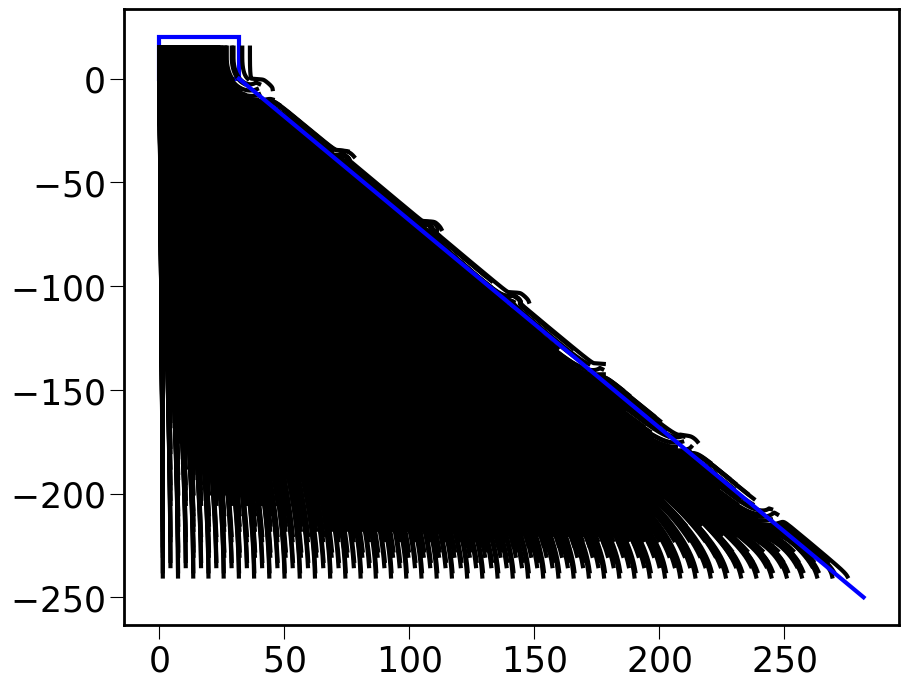

In [51]:
for i, line in data.groupby("id"):
    if i%2: continue

    plt.plot(line.r, line.z, "k-")

r = plt.Rectangle((0,0), 32, 20, facecolor="None", edgecolor="b")
plt.gca().add_patch(r)

l = plt.plot([32, 32+250], [0, -250], color="b")
#plt.gca().add_patch(l)
#plt.xlim(0, 20)
#plt.ylim(0, 20)


In [98]:
def rmax_at(z):
    return np.where(z<0, 32 - z, 32)

def hits_the_wall(line, dmin):
    delta = line.r - rmax_at(line.z)
    return np.any(delta > -dmin)

In [92]:
data = data.groupby("id").filter(lambda df: df.r.iloc[0] < rmax_at(df.z.iloc[0]))

In [57]:
data = data.drop(columns="delta_dist total_dist".split())

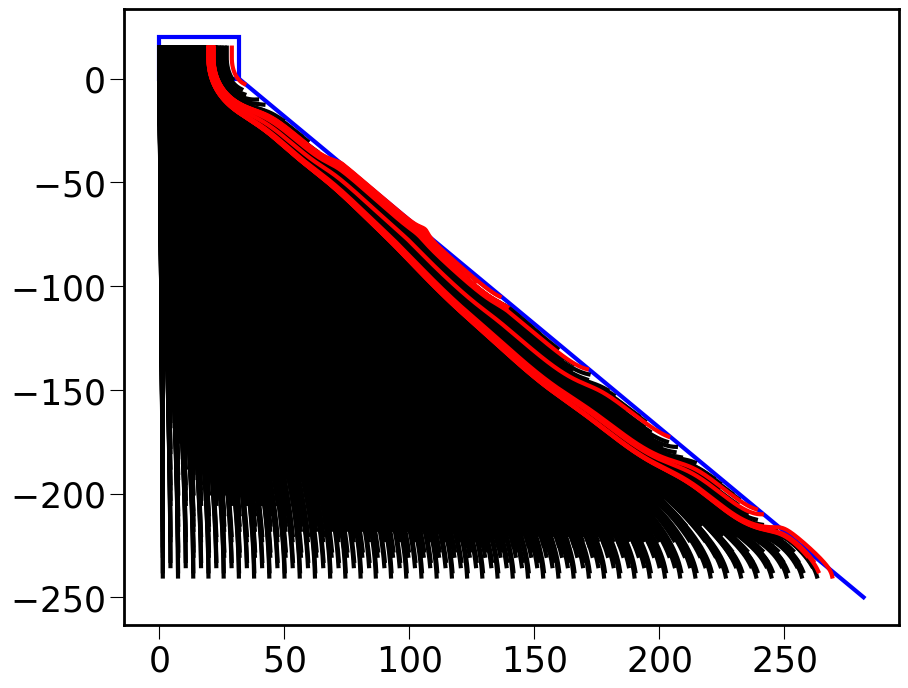

In [96]:
for i, line in data.groupby("id"):
    if i%2: continue

    bad = hits_the_wall(line)
    c = "r" if bad else "k"
    o = i + (10000 if bad else 0)
    plt.plot(line.r, line.z, c+"-", zorder=o)

r = plt.Rectangle((0,0), 32, 20, facecolor="None", edgecolor="b")
plt.gca().add_patch(r)

l = plt.plot([32, 32+250], [0, -250], color="b")
#plt.gca().add_patch(l)
#plt.xlim(0, 20)
#plt.ylim(0, 20)


In [99]:
el   = data.groupby("id").last()
cath = data.groupby("id").first()
disc = data.groupby("id").apply(hits_the_wall, dmin=2).to_frame().rename(columns={0: "out"})
corr = pd.DataFrame.join(el, cath, lsuffix="_el", rsuffix="_cath")
corr = pd.DataFrame.join(corr, disc)
cor  = corr.reset_index()

corr.z_cath = np.round(corr.z_cath, 4)

In [100]:
el

,r,z,field
id,,,
0,0.200830,15.0,8000.000000
1,0.602438,15.0,8000.000000
2,1.003705,15.0,8000.000000
3,1.404427,15.0,8000.000000
4,1.804342,15.0,8000.000000
...,...,...,...
4995,13.142880,15.0,8000.000003
4996,10.247137,15.0,8000.000001
4997,7.332247,15.0,8000.000000


In [101]:
cath

,r,z,field
id,,,
0,1.522253,-2.400000e+02,85.042063
1,4.566758,-2.400000e+02,84.994631
2,7.611264,-2.400000e+02,84.897484
3,10.655769,-2.400000e+02,84.750750
4,13.700275,-2.400000e+02,84.555599
...,...,...,...
4995,13.893750,0.000000e+00,4788.737061
4996,10.806250,0.000000e+00,4636.505242
4997,7.718750,-1.550793e-17,4529.433010


In [102]:
corr

,r_el,z_el,field_el,r_cath,z_cath,field_cath,out
id,,,,,,,
0,0.200830,15.0,8000.000000,1.522253,-240.0,85.042063,False
1,0.602438,15.0,8000.000000,4.566758,-240.0,84.994631,False
2,1.003705,15.0,8000.000000,7.611264,-240.0,84.897484,False
3,1.404427,15.0,8000.000000,10.655769,-240.0,84.750750,False
4,1.804342,15.0,8000.000000,13.700275,-240.0,84.555599,False
...,...,...,...,...,...,...,...
4995,13.142880,15.0,8000.000003,13.893750,0.0,4788.737061,False
4996,10.247137,15.0,8000.000001,10.806250,0.0,4636.505242,False
4997,7.332247,15.0,8000.000000,7.718750,-0.0,4529.433010,False


In [105]:
corr.z_cath.unique()

array([-240. , -237.5, -235. , -232.5, -230. , -227.5, -225. , -222.5,
       -220. , -217.5, -215. , -212.5, -210. , -207.5, -205. , -202.5,
       -200. , -197.5, -195. , -192.5, -190. , -187.5, -185. , -182.5,
       -180. , -177.5, -175. , -172.5, -170. , -167.5, -165. , -162.5,
       -160. , -157.5, -155. , -152.5, -150. , -147.5, -145. , -142.5,
       -140. , -137.5, -135. , -132.5, -130. , -127.5, -125. , -122.5,
       -120. , -117.5, -115. , -112.5, -110. , -107.5, -105. , -102.5,
       -100. ,  -97.5,  -95. ,  -92.5,  -90. ,  -87.5,  -85. ,  -82.5,
        -80. ,  -77.5,  -75. ,  -72.5,  -70. ,  -67.5,  -65. ,  -62.5,
        -60. ,  -57.5,  -55. ,  -52.5,  -50. ,  -47.5,  -45. ,  -42.5,
        -40. ,  -37.5,  -35. ,  -32.5,  -30. ,  -27.5,  -25. ,  -22.5,
        -20. ,  -17.5,  -15. ,  -12.5,  -10. ,   -7.5,   -5. ,   -2.5,
          0. ])

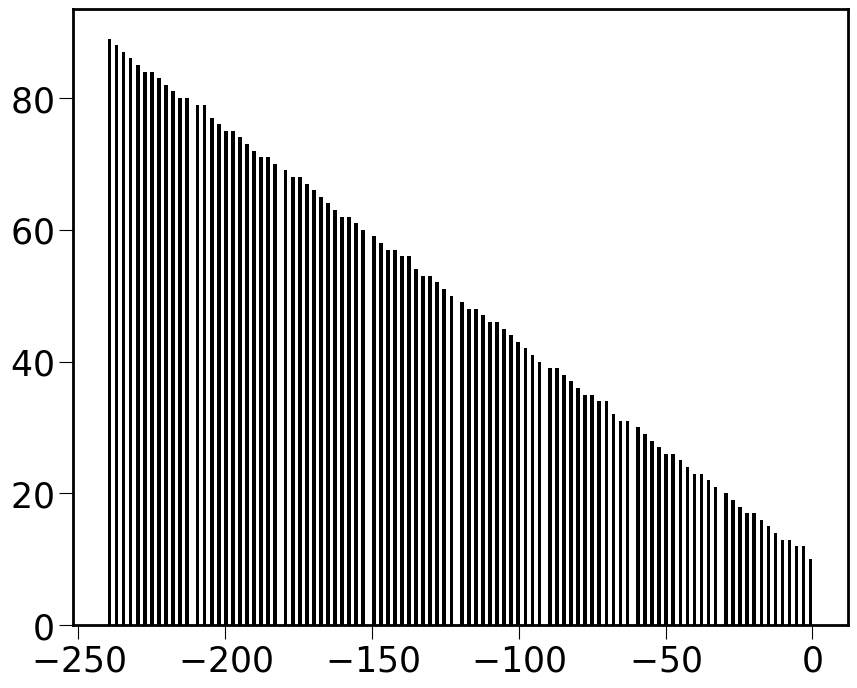

In [106]:
plt.hist(corr.z_cath, 200);

In [79]:
def fiducialize_fromel(df, cuts):
    ntot = len(df)
    ns   = []
    rmax = []
    for cut in cuts:
        df2 = df.loc[df.r_el<cut]
        ns  .append(len(df2))
        rmax.append(df2.r_cath.max())
    return pd.DataFrame(dict(survived=np.array(ns)/ntot, rmax=rmax), index=pd.Series(cuts, name="cut"))

In [27]:
cuts = 32 - np.linspace(0, 4, 21)
fiducial = corr.loc[corr.z_el > 14.99].groupby("z_cath").apply(fiducialize, cuts).reset_index()
fiducial

,z_cath,cut,survived,rmax
0,-240.0,32.0,1.000000,275.527747
1,-240.0,31.8,1.000000,275.527747
2,-240.0,31.6,1.000000,275.527747
3,-240.0,31.4,1.000000,275.527747
4,-240.0,31.2,1.000000,275.527747
...,...,...,...,...
2032,0.0,28.8,0.833333,29.331250
2033,0.0,28.6,0.833333,29.331250
2034,0.0,28.4,0.833333,29.331250
2035,0.0,28.2,0.833333,29.331250


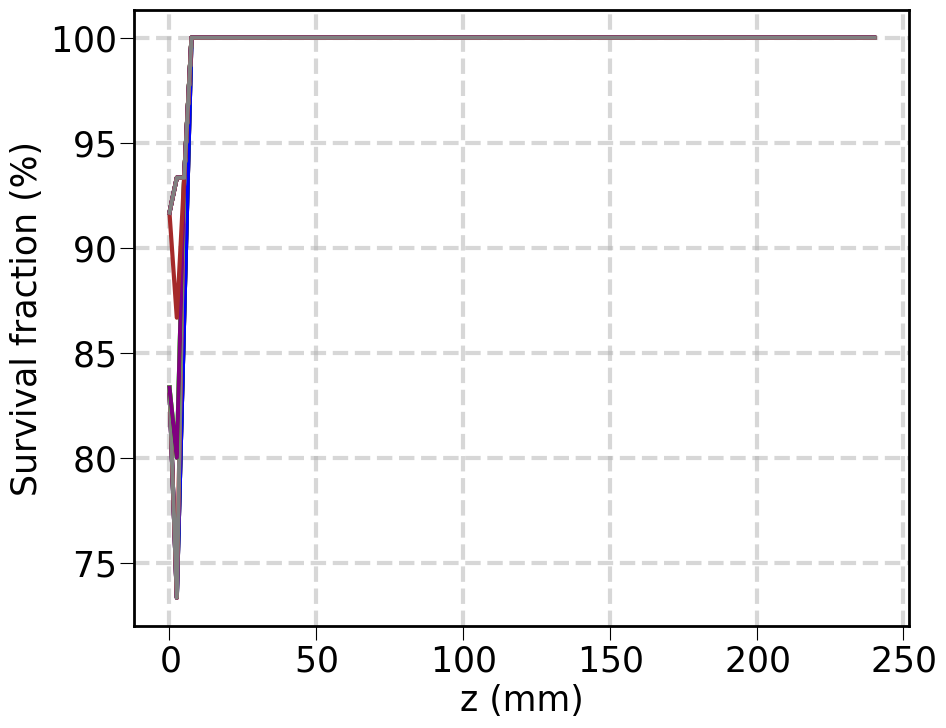

In [28]:
for cut, df in fiducial.groupby("cut"):
    plt.plot(-df.z_cath, df.survived*100)
plt.xlabel("z (mm)")
plt.ylabel("Survival fraction (%)")
plt.grid()

# Facelo ao revés, para cada z, a ver onde chegan

In [107]:
def fiducialize(df, cuts):
    ntot = len(df)
    ns   = []
    rmax = []
    for cut in cuts:
        df2 = df.loc[(df.r_el<cut) & ~df.out]
        ns  .append(len(df2))
        rmax.append(df2.r_cath.max())
    return pd.DataFrame(dict(survived=np.array(ns)/ntot, rmax=rmax), index=pd.Series(cuts, name="cut"))

In [108]:
cuts = 32 - np.linspace(0, 6, 21)
fiducial = corr.groupby("z_cath").apply(fiducialize, cuts).reset_index()
fiducial

,z_cath,cut,survived,rmax
0,-240.0,32.0,0.977528,263.349725
1,-240.0,31.7,0.977528,263.349725
2,-240.0,31.4,0.977528,263.349725
3,-240.0,31.1,0.977528,263.349725
4,-240.0,30.8,0.977528,263.349725
...,...,...,...,...
2032,0.0,27.2,1.000000,29.331250
2033,0.0,26.9,0.900000,26.243750
2034,0.0,26.6,0.900000,26.243750
2035,0.0,26.3,0.900000,26.243750


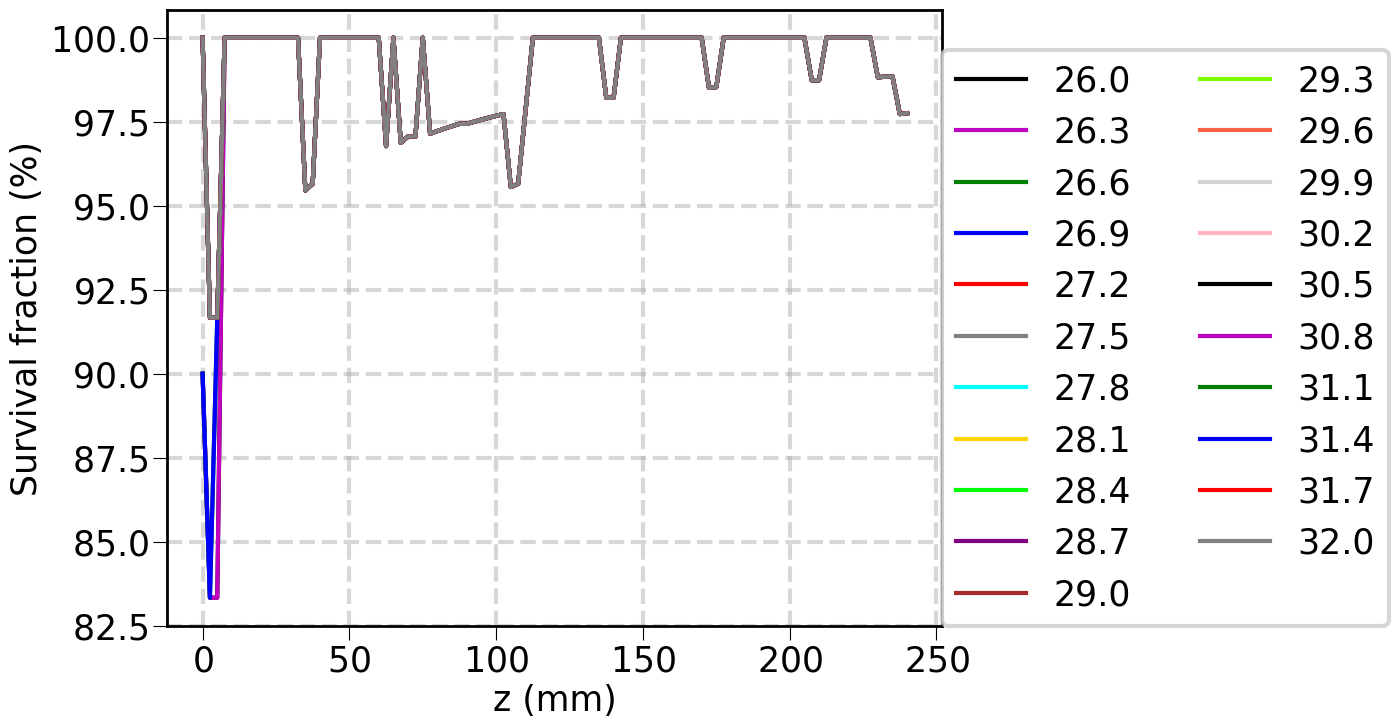

In [110]:
for cut, df in fiducial.groupby("cut"):
    plt.plot(-df.z_cath, df.survived*100, label=str(cut))
plt.legend(loc=(1,0), ncol=2)
plt.xlabel("z (mm)")
plt.ylabel("Survival fraction (%)")
plt.grid()

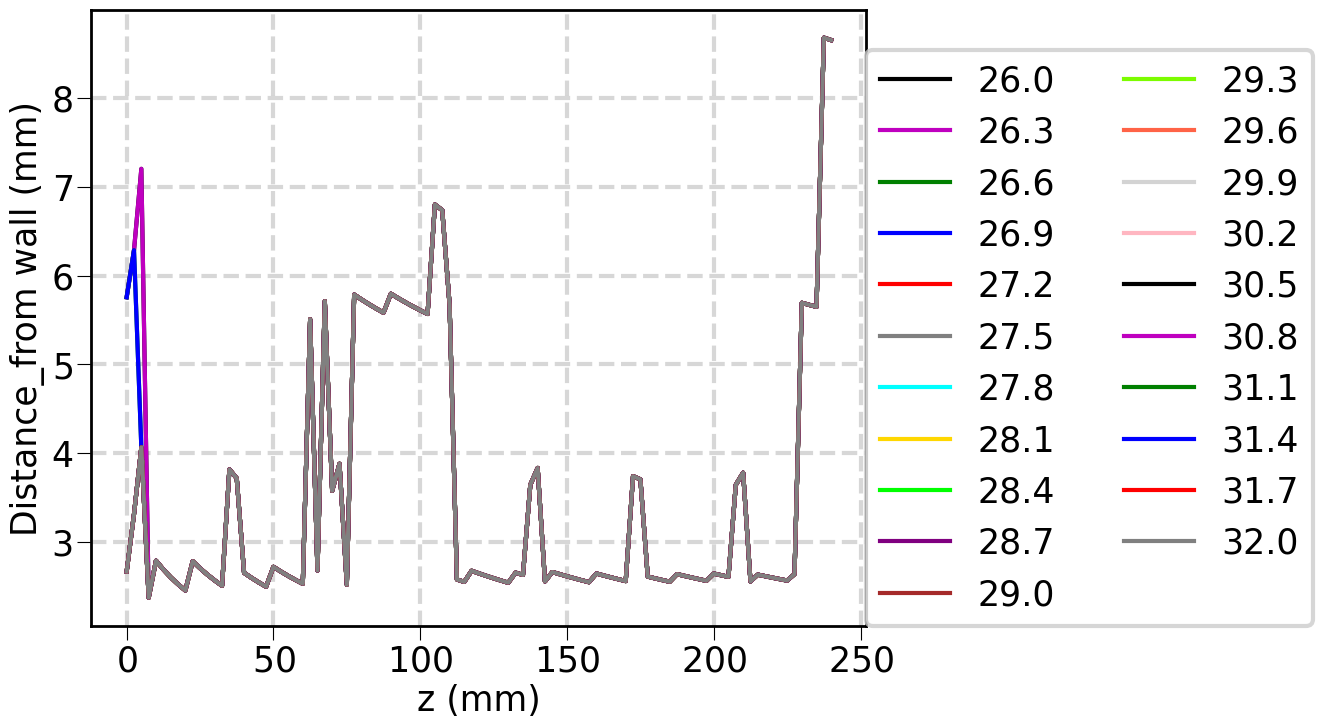

In [115]:
for cut, df in fiducial.groupby("cut"):
    plt.plot(-df.z_cath, -df.rmax + rmax_at(df.z_cath), label=str(cut))
    
#plt.plot([0, 240], [32, 32+240], "--m")
plt.legend(loc=(1,0), ncol=2)
plt.xlabel("z (mm)")
plt.ylabel("Distance_from wall (mm)")
plt.grid()

In [139]:
dz  = np.diff(sorted(df.z_cath.unique()))[0]
total_volume = np.pi * rmax_at(df.z_cath)**2 * dz
def compute_volume(df):
    volume = np.pi * df.rmax**2 * dz
    return (volume/total_volume).mean()

In [140]:
fid = (fiducial.groupby("cut")
               .apply(compute_volume)
               .reset_index()
               .rename(columns={0: "frac"})
      )
fid

,cut,frac
0,26.0,0.936201
1,26.3,0.936201
2,26.6,0.937683
3,26.9,0.937683
4,27.2,0.940938
5,27.5,0.940938
6,27.8,0.940938
7,28.1,0.940938
8,28.4,0.940938
9,28.7,0.940938


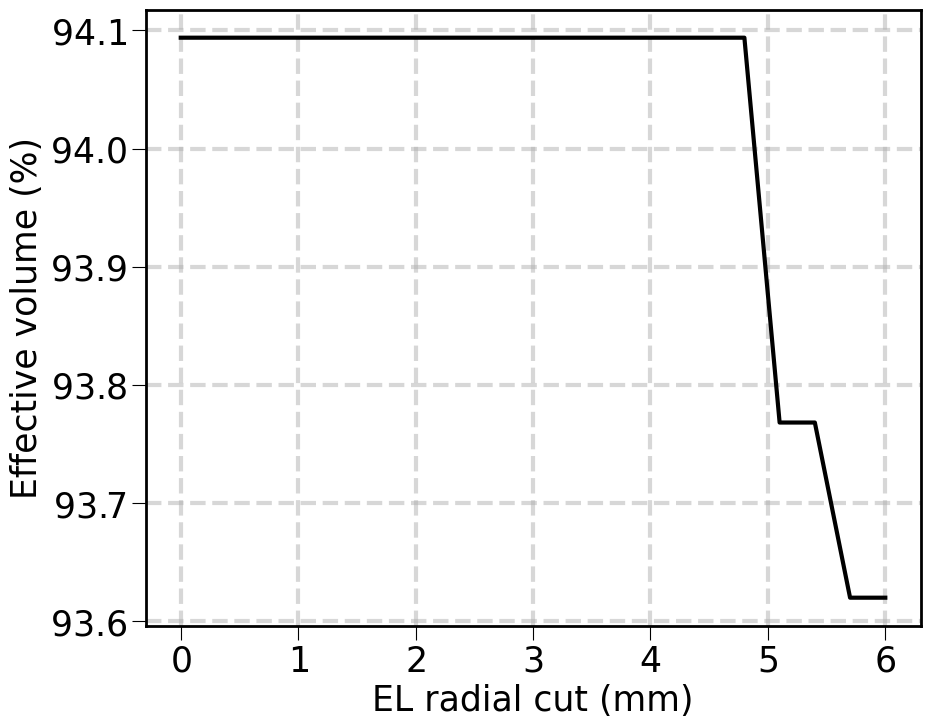

In [142]:
plt.plot(32-fid.cut, fid.frac*100)
plt.xlabel("EL radial cut (mm)")
plt.ylabel("Effective volume (%)")
plt.grid()